<a href="https://colab.research.google.com/github/Tuchobm/Curso-IA-Google-Colab/blob/main/3_2_reduc_dim_result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Aprendizaje no Supervisado - Reducción de Dimensionalidad

En este ejercicio se aplican técnicas de reducción de dimensiones para luego entrenar un modelo de clasificación. Se han de experimentar con las diferentes tecnicas de reducción de dimensiones y observar cómo afectan al rendimiento del modelo.

Además, encontrarás partes del código contendrán  el comentario de `# ACTIVIDAD` que indican dónde debes completar el código o realizar tareas específicas. Asegúrate de seguir las instrucciones y completar el código donde se indique. Finalmente, en el final de este ejercicio, deberás responder a una serie de preguntas.

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

data = load_digits()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.insert(0, "target", data.target)

entrenamiento, prueba = train_test_split(df, test_size=0.2, random_state=0)
# Añade ruido a los datos de prueba
prueba.iloc[:, 1:] += np.random.normal(0.1, 2, prueba.iloc[:, :-1].shape)

# Visualización de datos

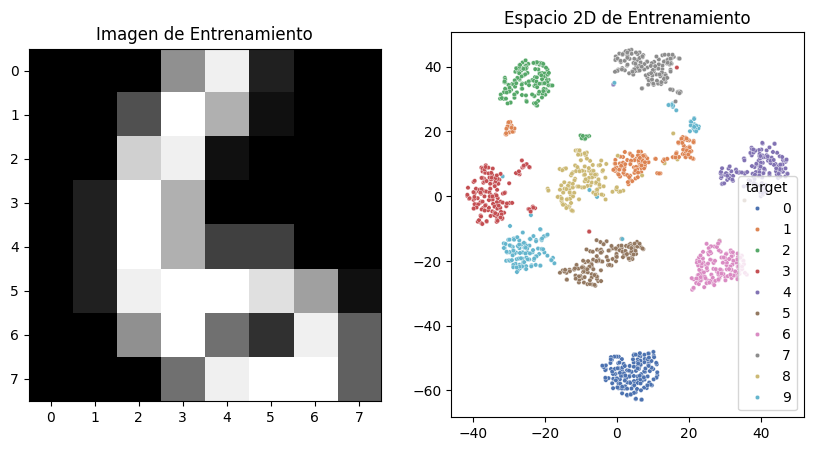

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Muestra una imagen de entrenamiento
ax[0].imshow(entrenamiento.iloc[0, 1:].values.reshape(8, 8), cmap="gray")
ax[0].set_title("Imagen de Entrenamiento")
# ACTIVIDAD: Reducir la dimensionalidad a 2D usando t-SNE
tsne = TSNE(n_components=2, random_state=0)
X_embedded = tsne.fit_transform(entrenamiento.drop(columns="target"))
# ACTIVIDAD: Mostrar el espacio 2D de los datos de entrenamiento
sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=entrenamiento["target"],
    palette="deep",
    ax=ax[1],
    s=10,
    legend="full",
)
ax[1].set_title("Espacio 2D de Entrenamiento")
plt.show()

# Entrenamiento y evaluación de un modelo de clasificación

In [ ]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

# ACTIVIDAD: Probar las diferentes tecnicas de reducción de dimensionalidad
pipe = Pipeline(
    [
        ("scaler", MinMaxScaler()),
        ("reductor", PCA(n_components=2, random_state=0)),
        ("model", DecisionTreeClassifier(max_depth=3, random_state=0)),
    ]
)

In [ ]:
pipe.fit(entrenamiento.drop(columns="target"), entrenamiento.target)

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('reductor', PCA(n_components=2, random_state=0)),
                ('model', DecisionTreeClassifier(max_depth=3, random_state=0))])

In [ ]:
from sklearn.metrics import accuracy_score


def score_pred(df):
    X = df.drop(columns="target")
    y_pred = pipe.predict(X)
    print(f"Acuraccy: {accuracy_score(df['target'], y_pred):.4f}")


score_pred(entrenamiento)
score_pred(prueba)

Acuraccy: 0.4600
Acuraccy: 0.3972


Ejemplo de como buscar Hiperparámetros de un model:
```python
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

model = RandomForestClassifier()
search_parms = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
search = RandomizedSearchCV(model, search_parms, n_iter=10, cv=3, verbose=1, n_jobs=-1)
search.fit(X, y)
print("Mejores hiperparámetros:", search.best_params_)
```

In [ ]:
# P3: Encuentra valor óptimo de n_components para PCA y SVD

# best_score = None
# best_n_components = None
# for n_components in range(2, len(entrenamiento.columns) - 1):
#     pipe = Pipeline(
#         [
#             ("scaler", MinMaxScaler()),
#             ("reductor", PCA(n_components=n_components, random_state=0)),
#             ("model", DecisionTreeClassifier(max_depth=3, random_state=0)),
#         ]
#     )
#     pipe.fit(entrenamiento.drop(columns="target"), entrenamiento.target)

#     y_pred = pipe.predict(entrenamiento.drop(columns="target"))
#     score = accuracy_score(entrenamiento["target"], y_pred)
#     if best_score is None or score > best_score:
#         best_score = score
#         best_n_components = n_components
# print(f"Mejor n_components: {best_n_components}")
# print(f"Mejor score: {best_score:.4f}")


from sklearn.model_selection import GridSearchCV

grid_params = {
    "reductor__n_components": range(2, len(entrenamiento.columns) - 1),
}
grid = GridSearchCV(
    pipe,
    grid_params,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
)
grid.fit(entrenamiento.drop(columns="target"), entrenamiento.target)
print(f"Mejor n_components: {grid.best_params_['reductor__n_components']}")
print(f"Mejor score: {grid.best_score_:.4f}")

Mejor n_components: 3
Mejor score: 0.4850


Text(0.5, 1.0, 'Espacio 2D de Entrenamiento (SVD)')

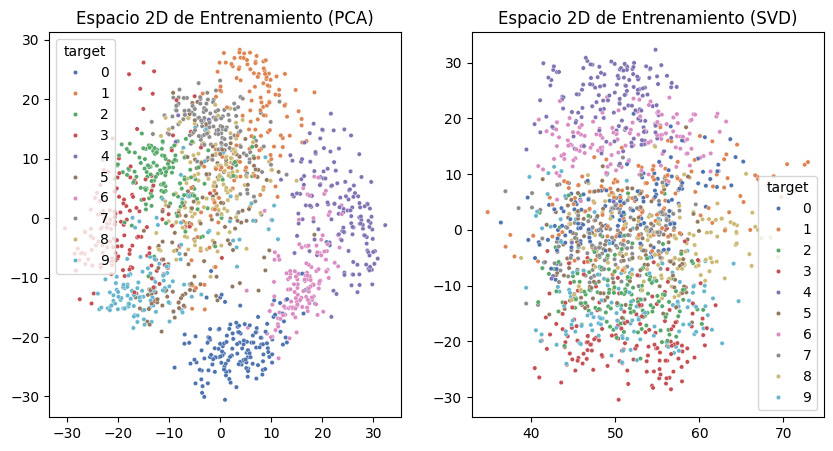

In [ ]:
# P4: - Visualiza los datos en 2D con PCA y SVD. ¿Puedes observar alguna agrupación en los datos después de aplicar PCA y SVD?
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(entrenamiento.drop(columns="target"))

svd = TruncatedSVD(n_components=2, random_state=0)
X_svd = svd.fit_transform(entrenamiento.drop(columns="target"))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=entrenamiento["target"],
    palette="deep",
    ax=ax[0],
    s=10,
    legend="full",
)
ax[0].set_title("Espacio 2D de Entrenamiento (PCA)")
sns.scatterplot(
    x=X_svd[:, 0],
    y=X_svd[:, 1],
    hue=entrenamiento["target"],
    palette="deep",
    ax=ax[1],
    s=10,
    legend="full",
)
ax[1].set_title("Espacio 2D de Entrenamiento (SVD)")

# Preguntas

- ¿Puedes observar alguna agrupación en los datos después de aplicar T-SNE? ¿Qué label pertenecé la agrupación que está más a la abajo?
  * Sí, se puede observar que los datos se agrupan en diferentes regiones del espacio, lo que indica que hay patrones en los datos que pueden ser utilizados para la clasificación.
  * La agrupación que está más abajo pertenece a la clase 0.
- ¿Qué valores de accuracy has obtenido con cada técnica de reducción de dimensionalidad? ¿Es mejor que el modelo sin la etapa de reducción de dimensionalidad?
  * Sin reducción de dimensionalidad: 0.3417
  * PCA: 0.3944
  * SVD: 0.3667
- ¿Qué pasaría con la precisión (accuracy) si aumentaras este número? ¿Cuál es el número óptimo de componentes para PCA y SVD? (Podeis probar de usar GridSearchCV para encontrar el número óptimo de componentes)
  * Aumentar el número de componentes puede mejorar la precisión del modelo, pero también puede llevar a un sobreajuste si se utilizan demasiados componentes. El número óptimo de componentes para PCA y SVD depende del conjunto de datos y debe ser determinado mediante validación cruzada.
  * PCA: 4 (accuracy=0.4823)
  * SVD: 3 (accuracy=0.4850)
- Visualiza los datos en 2D con PCA y SVD. ¿Puedes observar alguna agrupación en los datos después de aplicar PCA y SVD?
  * Es más difícil observar grupos sin colisiones tanto en PCA como en SVD. En general, PCA parece que separa mejor los datos que SVD. Podemos observar como el dígito 0 se encuentra en la parte inferior de la gráfica sin colisiones.
- ¿Para qué sirve la reducción de dimensionalidad? ¿Qué casos de uso se te ocurren?
  * La reducción de dimensionalidad es útil para simplificar los datos, eliminar ruido y mejorar la eficiencia del modelo. Algunos casos de uso incluyen la visualización de datos, la compresión de datos y la mejora del rendimiento del modelo al reducir el riesgo de overfitting.